# 06 — EDA Natation

**Objectif** : Explorer les splits natation du dataset triathlon (Sprint 750m / Olympic 1500m / Half 1900m / Full 3800m)  
pour comprendre la distribution des performances, l'impact de l'âge et du genre, et préparer la modélisation.

**Source** : vladislavboyadzhi/triathlon-results (Kaggle) — 2,96M résultats d'épreuves triathlon 2012-2022  
**Distances natation** : Sprint=750m | Olympic=1500m | Half=1900m | Full=3800m

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
RAW_PATH = '../data/raw/swimming/triathlon_results.csv'

def parse_time(t):
    if pd.isna(t) or t == '0:00' or t == '' or str(t).strip() == '0:00:00':
        return np.nan
    try:
        parts = str(t).strip().split(':')
        if len(parts) == 3:
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
        elif len(parts) == 2:
            return int(parts[0]) * 60 + int(parts[1])
    except:
        return np.nan

def age_from_group(group):
    try:
        nums = ''.join(c if c.isdigit() or c == '-' else ' ' for c in str(group)).strip()
        parts = nums.split('-')
        parts = [p.strip() for p in parts if p.strip().isdigit()]
        if len(parts) == 2:
            return (int(parts[0]) + int(parts[1])) / 2
        elif len(parts) == 1:
            return int(parts[0])
    except:
        return np.nan

chunks = []
for chunk in pd.read_csv(RAW_PATH, chunksize=100000):
    mask = chunk['event_link'].str.contains('/sprint/|/olympic/|/half/|/full/', na=False)
    sub = chunk[mask].copy()
    sub['swim_sec'] = sub['person_event_swim_time_text'].apply(parse_time)
    sub['age'] = sub['person_event_group'].apply(age_from_group)
    sub['gender'] = sub['gender'].map({'M': 0, 'F': 1})
    sub['race_format'] = sub['event_link'].str.extract(r'/(sprint|olympic|half|full)/')
    sub = sub[['race_format', 'gender', 'age', 'swim_sec']].dropna()
    chunks.append(sub)

df = pd.concat(chunks, ignore_index=True)
print(f'Lignes chargées : {len(df):,}')
print(df['race_format'].value_counts())

Lignes chargées : 2,623,271
race_format
half       1399026
full        951731
olympic     178787
sprint       93727
Name: count, dtype: int64


In [3]:
DIST_M = {'sprint': 750, 'olympic': 1500, 'half': 1900, 'full': 3800}
df['dist_m'] = df['race_format'].map(DIST_M)
df['pace_per_100m'] = df['swim_sec'] / (df['dist_m'] / 100)

# Filtrer aberrations (allure < 45s/100m trop rapide, > 5min/100m trop lent)
df = df[(df['pace_per_100m'] >= 45) & (df['pace_per_100m'] <= 300)]
df = df[(df['age'] >= 15) & (df['age'] <= 80)]
print(f'Après nettoyage : {len(df):,}')
df.describe()

Après nettoyage : 2,593,568


,gender,age,swim_sec,dist_m,pace_per_100m
count,2593568.00,2593568.00,2593568.00,2593568.00,2593568.00
mean,0.22,40.28,3121.31,2527.57,124.36
std,0.42,9.89,1338.52,986.92,27.20
min,0.00,15.00,338.00,750.00,45.00
25%,0.00,32.00,2125.00,1900.00,106.63
50%,0.00,42.00,2673.00,1900.00,121.34
75%,0.00,47.00,4177.00,3800.00,138.53
max,1.00,80.00,10361.00,3800.00,300.00


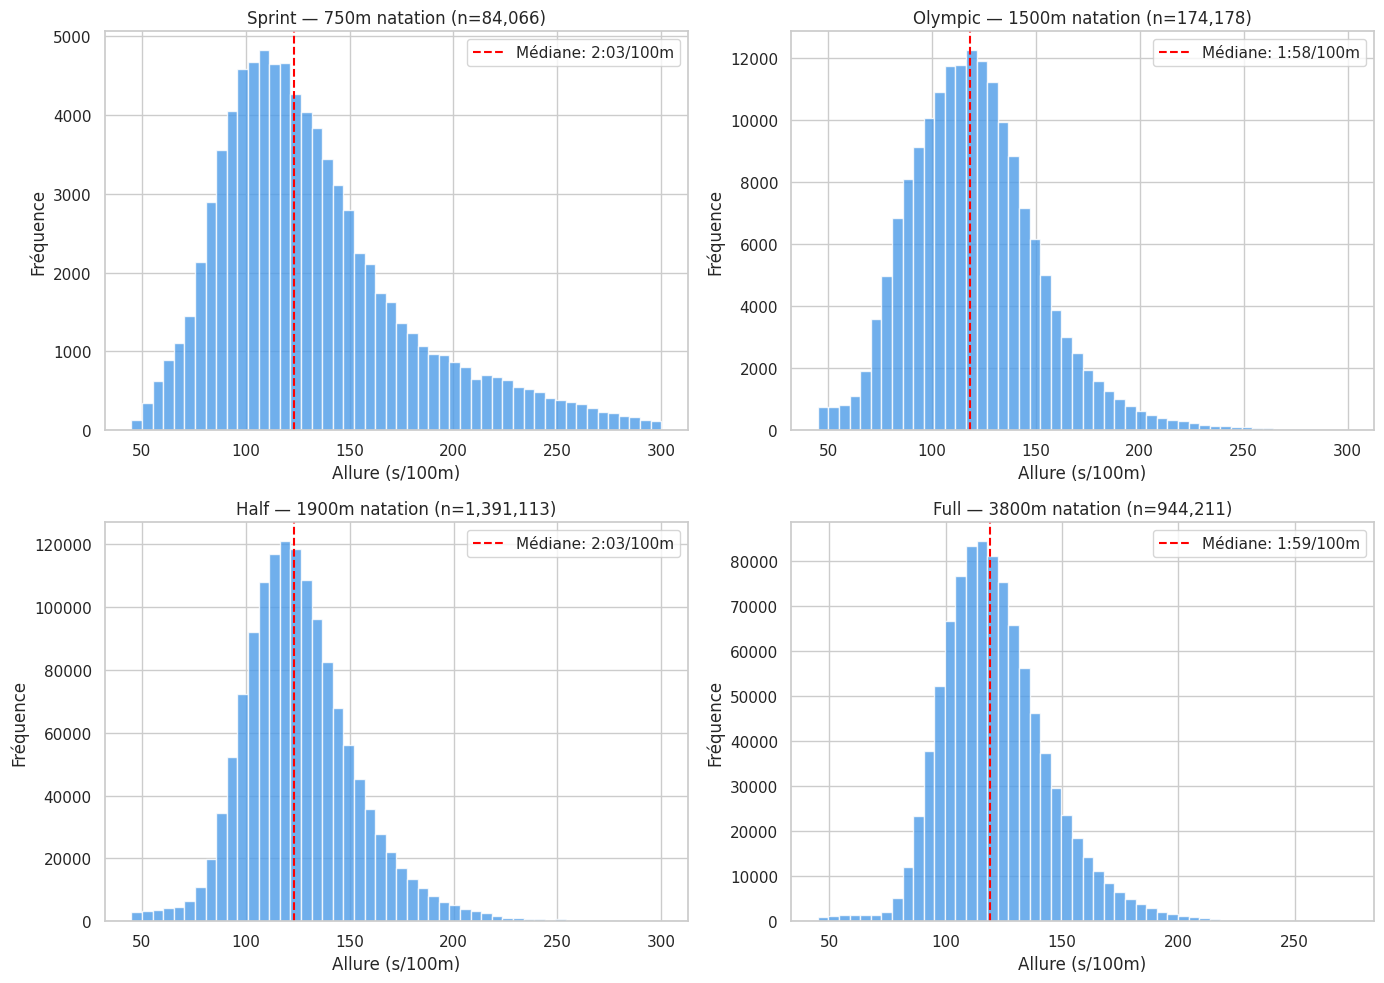

In [4]:
# Distribution allure par format
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (fmt, dist) in zip(axes.flatten(), DIST_M.items()):
    sub = df[df['race_format'] == fmt]
    ax.hist(sub['pace_per_100m'], bins=50, color='#4C9BE8', edgecolor='white', alpha=0.8)
    ax.set_title(f'{fmt.capitalize()} — {dist}m natation (n={len(sub):,})')
    ax.set_xlabel('Allure (s/100m)')
    ax.set_ylabel('Fréquence')
    med = sub['pace_per_100m'].median()
    ax.axvline(med, color='red', linestyle='--', label=f'Médiane: {int(med//60)}:{int(med%60):02d}/100m')
    ax.legend()
plt.tight_layout()
plt.savefig('../docs/swimming_eda_pace_dist.png', dpi=100, bbox_inches='tight')
plt.show()

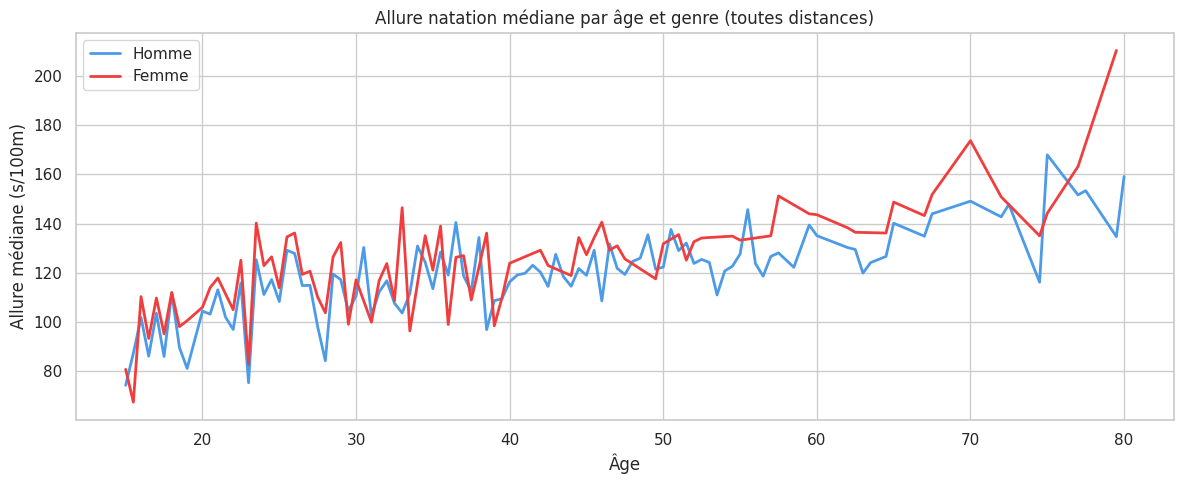

In [5]:
# Allure médiane par âge et genre
fig, ax = plt.subplots(figsize=(12, 5))
for gender_val, label, color in [(0, 'Homme', '#4C9BE8'), (1, 'Femme', '#F03E3E')]:
    sub = df[df['gender'] == gender_val]
    age_pace = sub.groupby('age')['pace_per_100m'].median()
    ax.plot(age_pace.index, age_pace.values, label=label, color=color, linewidth=2)
ax.set_xlabel('Âge')
ax.set_ylabel('Allure médiane (s/100m)')
ax.set_title('Allure natation médiane par âge et genre (toutes distances)')
ax.legend()
plt.tight_layout()
plt.show()

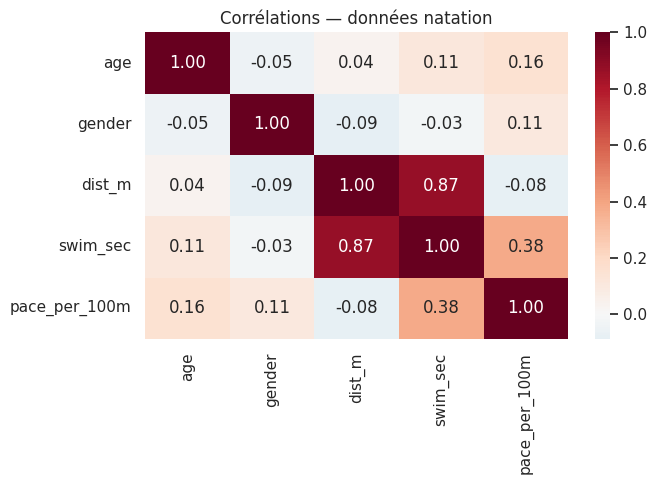


Stats par format de course:
              swim_sec                                                 \
                 count    mean    std     min     25%     50%     75%   
race_format                                                             
full         944211.00 4616.50 860.50 1710.00 4028.00 4522.00 5101.00   
half        1391113.00 2399.10 524.60  855.00 2056.00 2344.00 2678.00   
olympic      174178.00 1809.10 471.50  675.00 1483.00 1775.00 2076.00   
sprint        84066.00  996.70 347.60  338.00  753.00  925.00 1157.80   

                     pace_per_100m                                          \
                 max         count   mean   std   min    25%    50%    75%   
race_format                                                                  
full        10361.00     944211.00 121.50 22.60 45.00 106.00 119.00 134.20   
half         5700.00    1391113.00 126.30 27.60 45.00 108.20 123.40 140.90   
olympic      4500.00     174178.00 120.60 31.40 45.00  98.90 118.30 1

In [6]:
# Corrélation
corr = df[['age', 'gender', 'dist_m', 'swim_sec', 'pace_per_100m']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Corrélations — données natation')
plt.tight_layout()
plt.show()
print('\nStats par format de course:')
print(df.groupby('race_format')[['swim_sec', 'pace_per_100m']].describe().round(1))

In [7]:
df.to_csv('../data/processed/swimming_clean.csv', index=False)
print(f'Sauvegardé : {len(df):,} lignes -> data/processed/swimming_clean.csv')

Sauvegardé : 2,593,568 lignes -> data/processed/swimming_clean.csv
